# Stage 2 - INF2008 Group Project

## Part A - Advanced Data Preparation & Pipeline Engineering

* **Requirement:** Finalize CRISP-DM Phase 3. Implement robust handling for scaling, encoding, and missing values that go beyond the minimal basic cleaning required in Stage 1.
* **Constraint:** All data transformations and the estimator must be strictly encapsulated within a formal pipeline object (e.g., sklearn.pipeline.Pipeline). This proves the prevention of data leakage during validation.

In [1]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import FunctionTransformer, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.base import BaseEstimator, TransformerMixin
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from scipy.sparse import csr_matrix
import time
import gc

pd.set_option('display.width', 2000)
pd.set_option('display.max_columns', None)

### A-1 - Load CSV Data

In [2]:
data: pd.DataFrame = None

try:
    data = pd.read_csv('https://raw.githubusercontent.com/wilfredhuang/INF2008_MentalHealthAnalysis/refs/heads/master/data/raw/dataset.csv')
except Exception as e:
    print(f"Error loading data: {e}")

data

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety
...,...,...,...
53038,53038,Nobody takes me seriously I’ve (24M) dealt wit...,Anxiety
53039,53039,"selfishness ""I don't feel very good, it's lik...",Anxiety
53040,53040,Is there any way to sleep better? I can't slee...,Anxiety
53041,53041,"Public speaking tips? Hi, all. I have to give ...",Anxiety


### A-2 - Clean CSV Data

#### A-2-1 - Basic Data Cleaning

In [3]:
# Remove First Column
data = data.iloc[:, 1:]

# Remove Missing Values
data.dropna(inplace=True)

# Remove Duplicates
data.drop_duplicates(subset=['statement'], inplace=True)

data.reset_index(drop=True, inplace=True)

print(data)

                                               statement   status
0                                             oh my gosh  Anxiety
1      trouble sleeping, confused mind, restless hear...  Anxiety
2      All wrong, back off dear, forward doubt. Stay ...  Anxiety
3      I've shifted my focus to something else but I'...  Anxiety
4      I'm restless and restless, it's been a month n...  Anxiety
...                                                  ...      ...
51068  Anxiety cause faintness when standing up ? As ...  Anxiety
51069  anxiety heart symptom does anyone else have th...  Anxiety
51070  Travel Anxiety Hi all! Long time anxiety suffe...  Anxiety
51071  fomo from things i’m not involved in does anyo...  Anxiety
51072  Getting through the day How do you get  anythi...  Anxiety

[51073 rows x 2 columns]


### A-3 - Separate Data

To prevent any data leakage, we will separate the features and target variable before applying any encoders.

#### A-3-1 - Initiate X and y

In [4]:
X: pd.DataFrame = data[['statement']]
y: pd.Series = data['status']

#### A-3-2 - Train-Test Split

In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

### A-4 -  Prepare Data

#### A-4-1 - Feature Initial Pipeline Creation

The creation of the initial pipelines for the initial model testing are created here. These models are the extremely basic ones and are only meant to be used to test for the champion model.

In [6]:
text_columns: list[str] = ['statement']

# Clean Text Data
def clean_text(text_data) -> pd.Series:
    if isinstance(text_data, pd.DataFrame):
        text_data = text_data.iloc[:, 0]
    elif isinstance(text_data, np.ndarray):
        text_data = pd.Series(text_data.flatten())
    elif isinstance(text_data, list):
        text_data = pd.Series(text_data)

    return (
        text_data.astype(str)
        .str.lower()
        .str.replace(r'[^\w\s]', ' ', regex=True)
        .str.strip()
    )

initial_text_pipeline: Pipeline = Pipeline(steps=[
    ('cleaner', FunctionTransformer(clean_text, validate=False)),
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=1000))
])

initial_preprocessing_pipeline: ColumnTransformer = ColumnTransformer(transformers=[
    ('text', initial_text_pipeline, text_columns),
])

initial_models: dict[str, object] = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SGDClassifier(max_iter=1000, loss='hinge', random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
}

initial_pipelines: dict[str, Pipeline] = {
    name: Pipeline(steps=[
        ('preprocessing', initial_preprocessing_pipeline),
        ('classifier', model)
    ]) for name, model in initial_models.items()
}

#### A-4-2 - Target Encoding

In [7]:
# Encode Target Variable
status_encoder: LabelEncoder = LabelEncoder()

status_encoder.fit(y_train)

y_train_encoded = status_encoder.transform(y_train)
y_val_encoded = status_encoder.transform(y_val)
y_test_encoded = status_encoder.transform(y_test)

status_mapping: pd.DataFrame = pd.DataFrame({
    'status': status_encoder.classes_,
    'status_encoded': range(len(status_encoder.classes_))
})

status_mapping

,status,status_encoded
0,Anxiety,0
1,Bipolar,1
2,Depression,2
3,Normal,3
4,Personality disorder,4
5,Stress,5
6,Suicidal,6


## Part B: Champion Model Selection
* **Requirement:** Compare 2 to 3 distinct algorithmic families (e.g., a Linear/Distance-based model versus a Tree-based ensemble). You may also consider using a variety of them using model stacking approaches.
* **Deliverable:** Evaluate these base models using k-fold cross-validation (e.g., 5-fold) or a time-series split. Declare one model as the "Champion" based on the mean and standard deviation of your primary evaluation metric.

### B-1 - Compare Models

In [8]:
for name, pipe in initial_pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train_encoded, cv=5, scoring='accuracy')
    print(f"{name}: Mean={scores.mean():.4f}, Std={scores.std():.4f}")

Random Forest: Mean=0.7074, Std=0.0053
SVM: Mean=0.7387, Std=0.0039
Logistic Regression: Mean=0.7446, Std=0.0044


### B-2 - Select Champion

Logistic Regression is the champion here, having the highest mean score and relatively low standard deviation.

## Part C: Controlled Ablations & Tuning (The Champion)
* **Requirement:** Perform a maximum of 4 controlled experiments exclusively on the chosen Champion model. This may involve adding a specific engineered feature, applying a class balancing technique, or tuning a specific set of hyperparameters.
* **Deliverable:** An Ablation Log (Table) explicitly detailing: *Hypothesis, Controlled Change, CV Metric Impact (Mean ± Std Dev), and Conclusion*.

### C-0 - Base Model

#### C-0-1 - Create Pipelines

In [9]:
base_text_pipeline: Pipeline = Pipeline(steps=[
    ('cleaner', FunctionTransformer(clean_text, validate=False)),
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=1000))
])

base_preprocessing_pipeline: ColumnTransformer = ColumnTransformer(transformers=[
    ('text', base_text_pipeline, text_columns),
])

base_model_pipeline: Pipeline = Pipeline(steps=[
    ('preprocessing', base_preprocessing_pipeline),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

#### C-0-2 - Run Pipelines

In [32]:
base_model_cv_score_df: pd.DataFrame = pd.DataFrame(columns=['Mean', 'Std', 'Time Taken (s)'])

start_time = time.time()
base_model_cv_score = cross_val_score(base_model_pipeline, X_train, y_train_encoded, cv=5, scoring='accuracy')
end_time = time.time()

base_model_cv_score_df.loc[0] = {'Mean': base_model_cv_score.mean(), 'Std': base_model_cv_score.std(), 'Time Taken (s)': end_time - start_time}

#### C-0-3 Analyze Model Performance

In [11]:
print(base_model_cv_score_df)

       Mean       Std  Time Taken (s)
0  0.744628  0.004355       31.323379


#### C-0-4 - Free Memory (Optional)

In [12]:
# del base_model_cv_score
# del base_model_cv_score_df
# gc.collect()

407

### C-1 - Adding Class Balancing in Logistic Regression

#### C-1-1 - Create Pipelines

In [33]:
c1_pipeline_text: Pipeline = Pipeline(steps=[
    ('cleaner', FunctionTransformer(clean_text, validate=False)),
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=1000))
])

c1_pipeline_preprocessing: ColumnTransformer = ColumnTransformer(transformers=[
    ('text', c1_pipeline_text, text_columns),
])

c1_pipeline_model: Pipeline = Pipeline(steps=[
    ('preprocessing', c1_pipeline_preprocessing),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

#### C-1-2 - Run Pipelines

In [34]:
c1_model_cv_score_df: pd.DataFrame = pd.DataFrame(columns=['Mean', 'Std', 'Time Taken (s)'])

start_time = time.time()
c1_model_cv_score: np.ndarray = cross_val_score(c1_pipeline_model, X_train, y_train_encoded, cv=5, scoring='accuracy')
end_time = time.time()

c1_model_cv_score_df.loc[0] = {'Mean': c1_model_cv_score.mean(), 'Std': c1_model_cv_score.std(), 'Time Taken (s)': end_time - start_time}

#### C-1-3 Analyze Model Performance

In [15]:
print(c1_model_cv_score_df)

       Mean       Std  Time Taken (s)
0  0.718586  0.006243       29.829885


#### C-1-4 - Free Memory (Optional)

In [16]:
# del c1_model_cv_score
# del c1_model_cv_score_df
# gc.collect()

156

### C-2 - Richer TD-IDF ngram_range

#### C-2-1 - Create Pipelines

In [35]:
c2_pipeline_text: Pipeline = Pipeline(steps=[
    ('cleaner', FunctionTransformer(clean_text, validate=False)),
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=1000))
])

c2_pipeline_preprocessing: ColumnTransformer = ColumnTransformer(transformers=[
    ('text', c2_pipeline_text, text_columns),
])

c2_pipeline_model: Pipeline = Pipeline(steps=[
    ('preprocessing', c2_pipeline_preprocessing),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

#### C-2-2 - Run Pipelines

In [36]:
c2_model_cv_score_df: pd.DataFrame = pd.DataFrame(columns=['Ngram', 'Mean', 'Std', 'Time Taken (s)'])

for ngram in range(1, 4):
    c2_pipeline_text.set_params(tfidf__ngram_range=(1, ngram))
    start_time = time.time()
    c2_model_cv_score: np.ndarray = cross_val_score(c2_pipeline_model, X_train, y_train_encoded, cv=5, scoring='accuracy')
    end_time = time.time()
    c2_model_cv_score_df.loc[len(c2_model_cv_score_df)] = {'Ngram': ngram, 'Mean': c2_model_cv_score.mean(), 'Std': c2_model_cv_score.std(), 'Time Taken (s)': end_time - start_time}

#### C-2-3 - Analyze Model Performance

   Ngram      Mean       Std  Time Taken (s)
0      1  0.744628  0.004355       32.724696
1      2  0.741152  0.002873       56.215163
2      3  0.740932  0.002983       93.788357


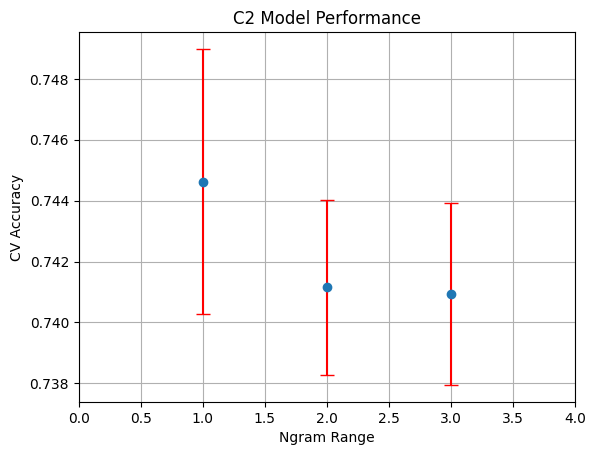

In [37]:
print(c2_model_cv_score_df)

plt.errorbar(
    c2_model_cv_score_df['Ngram'],
    c2_model_cv_score_df['Mean'],
    yerr=c2_model_cv_score_df['Std'],
    fmt='o',
    ecolor='red',
    capsize=5
)

plt.xlim(0, 4)
plt.xlabel('Ngram Range')
plt.ylabel('CV Accuracy')
plt.title('C2 Model Performance')
plt.grid()
plt.show()

#### C-2-4 - Free Memory (Optional)

In [20]:
# del c2_model_cv_score_df
# gc.collect()

3560

### C-3 - Changing C hyperparameter in LogisticRegression

#### C-3-1 - Create Pipelines

In [38]:
c3_pipeline_text: Pipeline = Pipeline(steps=[
    ('cleaner', FunctionTransformer(clean_text, validate=False)),
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=1000))
])

c3_pipeline_preprocessing: ColumnTransformer = ColumnTransformer(transformers=[
    ('text', c3_pipeline_text, text_columns),
])

c3_pipeline_model: Pipeline = Pipeline(steps=[
    ('preprocessing', c3_pipeline_preprocessing),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

#### C-3-2 - Run Pipelines

In [39]:
c3_model_cv_score_df: pd.DataFrame = pd.DataFrame(columns=['C', 'Mean', 'Std', 'Time Taken (s)'])

for C in np.arange(0.1, 2.1, 0.1):
    c3_pipeline_model.set_params(classifier__C=C)
    start_time = time.time()
    c3_model_cv_score: np.ndarray = cross_val_score(c3_pipeline_model, X_train, y_train_encoded, cv=5, scoring='accuracy')
    end_time = time.time()
    c3_model_cv_score_df.loc[len(c3_model_cv_score_df)] = {'C': C, 'Mean': c3_model_cv_score.mean(), 'Std': c3_model_cv_score.std(), 'Time Taken (s)': end_time - start_time}

#### C-3-3 - Analyze Model Performance

      C      Mean       Std  Time Taken (s)
0   0.1  0.708723  0.002351       24.383431
1   0.2  0.726712  0.003310       26.333978
2   0.3  0.734152  0.002471       27.029931
3   0.4  0.738068  0.003449       28.399429
4   0.5  0.740785  0.004204       29.070147
5   0.6  0.742474  0.004707       28.136870
6   0.7  0.743428  0.004529       30.350610
7   0.8  0.743893  0.004378       30.203755
8   0.9  0.744236  0.004480       30.193684
9   1.0  0.744628  0.004355       32.079231
10  1.1  0.744970  0.004697       30.813067
11  1.2  0.745411  0.004725       32.286058
12  1.3  0.745558  0.004899       31.154024
13  1.4  0.746561  0.004460       33.580943
14  1.5  0.745925  0.004778       33.980931
15  1.6  0.745925  0.004466       33.234771
16  1.7  0.745851  0.004944       35.145602
17  1.8  0.746194  0.004280       32.404563
18  1.9  0.746292  0.004416       35.448508
19  2.0  0.746170  0.004481       34.206438


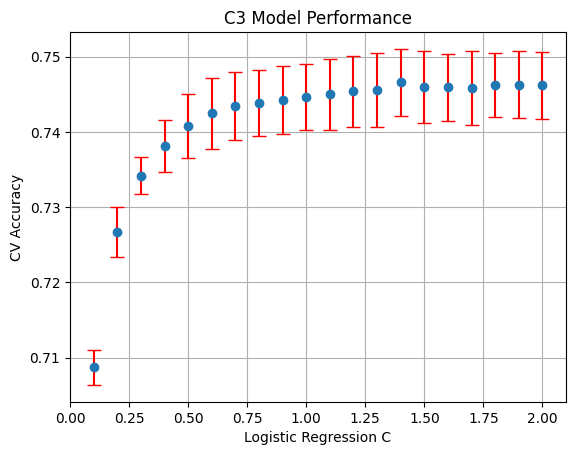

In [40]:
print(c3_model_cv_score_df)

plt.errorbar(
    x=c3_model_cv_score_df['C'],
    y=c3_model_cv_score_df['Mean'],
    yerr=c3_model_cv_score_df['Std'],
    fmt='o',
    ecolor='red',
    capsize=5
)

plt.xlim(0, 2.1)
plt.xlabel('Logistic Regression C')
plt.ylabel('CV Accuracy')
plt.title('C3 Model Performance')
plt.grid()
plt.show()

#### C-3-4 - Free Memory (Optional)

In [24]:
# del c3_model_cv_score_df
# gc.collect()

4269

### C-4 - Switch to SBERT

#### C-4-1 - Create Pipelines

In [41]:
def clean_text_sbert(X) -> np.array:
    if isinstance(X, pd.DataFrame):
        X = X.iloc[:, 0].astype(str).values
    elif isinstance(X, pd.Series):
        X = X.astype(str).values
    elif isinstance(X, np.ndarray):
        X = X.ravel().astype(str)
    else:
        raise ValueError("Unsupported input type in cleaner")

    return np.array([text.strip() for text in X], dtype=str)

class SBERTTransformer(BaseEstimator, TransformerMixin):
    _model_cache: dict[str, SentenceTransformer] = {}

    def __init__(self, model_name: str = 'all-MiniLM-L6-v2'):
        self.model_name = model_name
        self.model = None

    def fit(self, X, y=None):
        self._load_model()
        self.n_features_in_ = 1
        return self

    def _load_model(self):
        if self.model_name not in SBERTTransformer._model_cache:
            SBERTTransformer._model_cache[self.model_name] = SentenceTransformer(self.model_name)
        self.model = SBERTTransformer._model_cache[self.model_name]

    def transform(self, X):
        if self.model is None:
            self._load_model()

        if isinstance(X, pd.DataFrame):
            X = X.iloc[:, 0].astype(str).tolist()
        elif isinstance(X, pd.Series):
            X = X.astype(str).tolist()
        elif isinstance(X, np.ndarray):
            X = X.ravel().astype(str).tolist()
        elif isinstance(X, list):
            X = [str(t) for t in X]
        else:
            raise ValueError("Unsupported input type for SBERT transformer")

        return self.model.encode(X, show_progress_bar=True)

c4_pipeline_text: Pipeline = Pipeline(steps=[
    ('cleaner', FunctionTransformer(clean_text_sbert, validate=False)),
    ('sbert', SBERTTransformer('all-MiniLM-L6-v2'))
])

c4_pipeline_preprocessing: ColumnTransformer = ColumnTransformer(transformers=[
    ('text', c4_pipeline_text, text_columns)
])

c4_pipeline_model: Pipeline = Pipeline(steps=[
    ('preprocessing', c4_pipeline_preprocessing),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

#### C-4-2 - Run Pipelines

In [42]:
c4_model_cv_score_df: pd.DataFrame = pd.DataFrame(columns=['Mean', 'Std', 'Time Taken (s)'])

start_time = time.time()
c4_model_cv_score: np.ndarray = cross_val_score(c4_pipeline_model, X_train, y_train_encoded, cv=5, scoring='accuracy')
end_time = time.time()

c4_model_cv_score_df.loc[0] = {'Mean': c4_model_cv_score.mean(), 'Std': c4_model_cv_score.std(), 'Time Taken (s)': end_time - start_time}

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/1022 [00:00<?, ?it/s]

Batches:   0%|          | 0/256 [00:00<?, ?it/s]

Batches:   0%|          | 0/1022 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/256 [00:00<?, ?it/s]

Batches:   0%|          | 0/1022 [00:00<?, ?it/s]

Batches:   0%|          | 0/256 [00:00<?, ?it/s]

Batches:   0%|          | 0/1022 [00:00<?, ?it/s]

Batches:   0%|          | 0/256 [00:00<?, ?it/s]

#### C-4-3 - Analyze Model Performance

In [43]:
print(c4_model_cv_score_df)

       Mean       Std  Time Taken (s)
0  0.758823  0.003907      433.169797


#### C-4-4 - Free Memory (Optional)

In [28]:
# del c4_model_cv_score
# del c4_model_cv_score_df
# gc.collect()

182

### C-5 - Merge Datasets

       Model  Mean CV Accuracy  Std CV Accuracy  Time Taken (s)
0       Base          0.744628         0.004355       38.423491
1         C1          0.718586         0.006243       40.744275
2     C2 (1)          0.744628         0.004355       32.724696
3     C2 (2)          0.741152         0.002873       56.215163
4     C2 (3)          0.740932         0.002983       93.788357
5   C3 (0.1)          0.708723         0.002351       24.383431
6   C3 (0.2)          0.726712         0.003310       26.333978
7   C3 (0.3)          0.734152         0.002471       27.029931
8   C3 (0.4)          0.738068         0.003449       28.399429
9   C3 (0.5)          0.740785         0.004204       29.070147
10  C3 (0.6)          0.742474         0.004707       28.136870
11  C3 (0.7)          0.743428         0.004529       30.350610
12  C3 (0.8)          0.743893         0.004378       30.203755
13  C3 (0.9)          0.744236         0.004480       30.193684
14  C3 (1.0)          0.744628         0

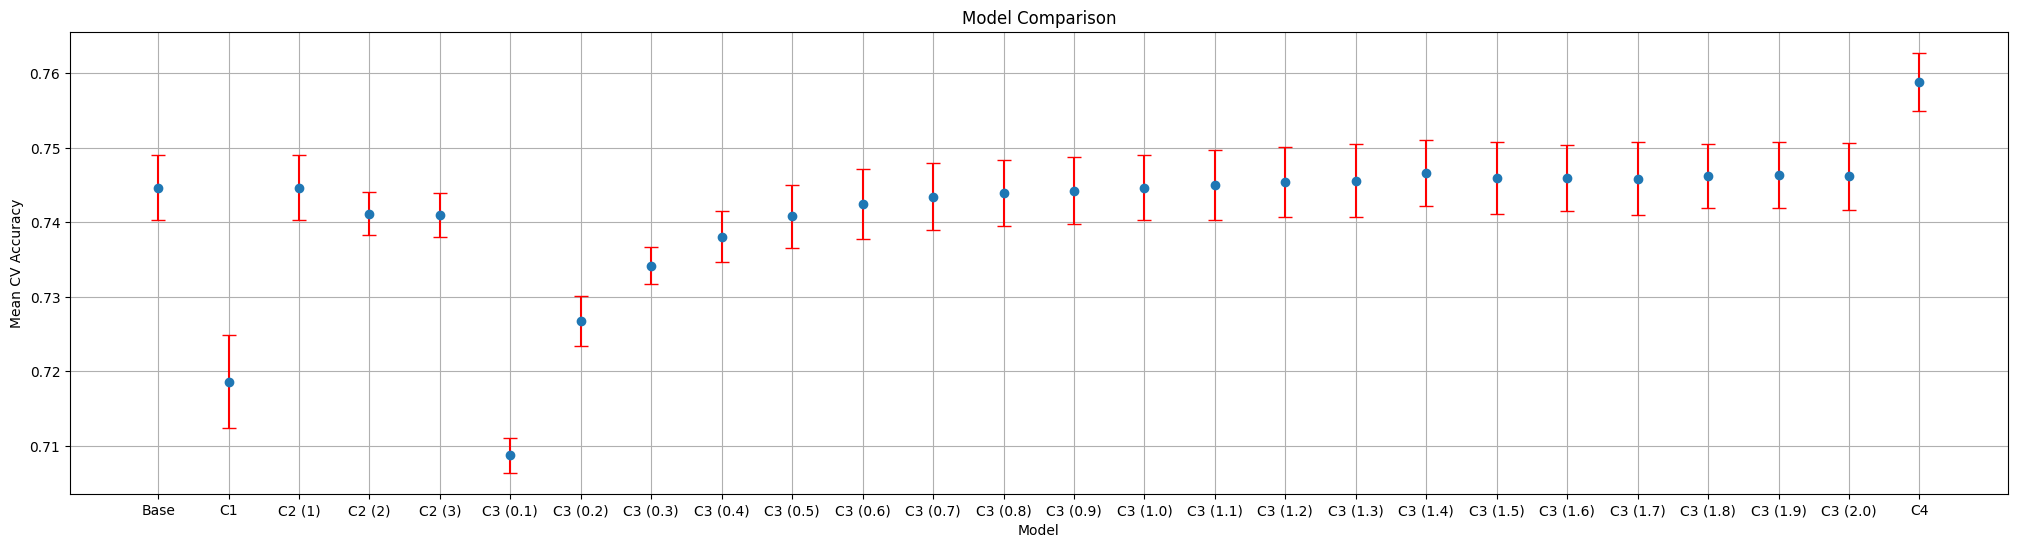

In [44]:
model_comparison_df: pd.DataFrame = pd.DataFrame(columns=['Model', 'Mean CV Accuracy', 'Std CV Accuracy', 'Time Taken (s)'])

model_comparison_df.loc[0] = ['Base', base_model_cv_score_df['Mean'][0], base_model_cv_score_df['Std'][0], base_model_cv_score_df['Time Taken (s)'][0]]

model_comparison_df.loc[1] = ['C1', c1_model_cv_score_df['Mean'][0], c1_model_cv_score_df['Std'][0], c1_model_cv_score_df['Time Taken (s)'][0]]

for i in range(len(c2_model_cv_score_df)):
    model_comparison_df.loc[len(model_comparison_df)] = [f"C2 ({c2_model_cv_score_df['Ngram'][i]})", c2_model_cv_score_df['Mean'][i], c2_model_cv_score_df['Std'][i], c2_model_cv_score_df['Time Taken (s)'][i]]

for i in range(len(c3_model_cv_score_df)):
    model_comparison_df.loc[len(model_comparison_df)] = [f"C3 ({c3_model_cv_score_df['C'][i]:.1f})", c3_model_cv_score_df['Mean'][i], c3_model_cv_score_df['Std'][i], c3_model_cv_score_df['Time Taken (s)'][i]]

for i in range(len(c4_model_cv_score_df)):
    model_comparison_df.loc[len(model_comparison_df)] = [f"C4", c4_model_cv_score_df['Mean'][i], c4_model_cv_score_df['Std'][i], c4_model_cv_score_df['Time Taken (s)'][i]]

print(model_comparison_df)

plt.figure(figsize=(25, 6))

plt.errorbar(
    x=model_comparison_df['Model'],
    y=model_comparison_df['Mean CV Accuracy'],
    yerr=model_comparison_df['Std CV Accuracy'],
    fmt='o',
    ecolor='red',
    capsize=5
)
plt.xlabel('Model')
plt.ylabel('Mean CV Accuracy')
plt.title('Model Comparison')
plt.grid()
plt.show()

## Part D: Mechanical Failure Analysis
* **Requirement:** Aggregate metrics obscure underlying model flaws. Inspect the raw validation data where the model was confidently incorrect.
* **For Classification:** Extract 5 to 10 instances of False Positives or False Negatives with high prediction confidence. Mechanically explain *why* the model failed on these specific instances based on their feature values, and propose a targeted technical fix.
* **For Regression:** Extract the 5 to 10 instances from your validation set that exhibit the highest absolute error (extreme under/over-predictions). Analyze the feature values of these specific extreme outliers to explain the failure and propose a technical fix.

### D-1 - Run Validation

In [45]:
selected_pipeline: Pipeline = c4_pipeline_model.fit(X_val, y_val_encoded)
y_val_pred: np.ndarray = selected_pipeline.predict(X_val)
confidence: np.ndarray = selected_pipeline.predict_proba(X_val).max(axis=1)

Batches:   0%|          | 0/160 [00:00<?, ?it/s]

Batches:   0%|          | 0/160 [00:00<?, ?it/s]

Batches:   0%|          | 0/160 [00:00<?, ?it/s]

### D-2 - Analyze Data

Confidence DataFrame
                                              Statement  True Label Predicted Label  Confidence
0               If you don't complain, you're not human      Normal          Normal    0.767990
1                                        Awikwok cuckoo      Normal          Normal    0.992344
2     zoo suggest df for kittens that smell a bit st...      Normal          Normal    0.810449
3                  Come on, what do you say to dreamies      Normal          Normal    0.978018
4                                     Ang init punyeta.      Normal          Normal    0.954348
...                                                 ...         ...             ...         ...
5102  I’m embarrassed to say this but I need help I’...  Depression      Depression    0.465021
5103            doe not know how he got home last night      Normal          Normal    0.991842
5104  i highly expect to get a lot of pushback on th...  Depression        Suicidal    0.476469
5105  First real jo

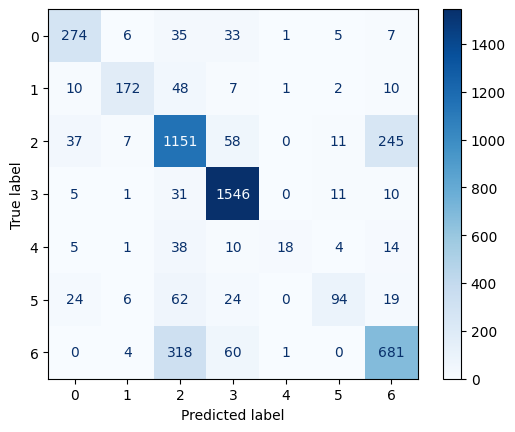

In [46]:
confidence_df: pd.DataFrame = pd.DataFrame(columns=['Statement', 'True Label', 'Predicted Label', 'Confidence'])
for i in range(len(X_val)):
    confidence_df.loc[i] = {
        'Statement': X_val.iloc[i]['statement'],
        'True Label': status_encoder.inverse_transform([y_val_encoded[i]])[0],
        'Predicted Label': status_encoder.inverse_transform([y_val_pred[i]])[0],
        'Confidence': confidence[i]
    }

print("Confidence DataFrame")
print(confidence_df)

print("Confusion Matrix")
ConfusionMatrixDisplay.from_predictions(y_val_encoded, y_val_pred, cmap=plt.cm.Blues)
plt.show()

### D-3 - Extract Confidently Wrong Predictions

In [47]:
confidently_wrong_mask: pd.Series = (confidence_df['Confidence'] > 0.8) & (confidence_df['True Label'] != confidence_df['Predicted Label'])
confidently_wrong_df: pd.DataFrame = confidence_df[confidently_wrong_mask]
confidently_wrong_df.sort_values(by='Confidence', ascending=False, inplace=True)

pd.set_option('display.max_colwidth', None)
print(confidently_wrong_df.head(10))
pd.reset_option('display.max_colwidth')

                                                                                                                                                                                                                                                                                                                                                                                                                                                                             Statement  True Label Predicted Label  Confidence
395                                                                                                                                                                                                                                                                                                                                                                                                                       Only missing the alcohol and a quiet night. Letters written.    Suicidal       

/tmp/ipykernel_22687/2849250862.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  confidently_wrong_df.sort_values(by='Confidence', ascending=False, inplace=True)


### D-4 - Proposed Technical Fixes

1. Have more data to further differentiate suicidal and depression, or implement an additional model layer specialized in suicidal and depression statements.
2. Some data does not match the True Label at all. Improve initial data cleaning to handle these values.

## Part E: Decision Making
* Requirement: A model's raw output must be translated into a business decision. Default thresholds (0.5) are rarely optimal in the real world. You must logically evaluate the risks of your model's errors based on the context defined in Stage 1.
+2

* For Classification:
   * Identify which error is more damaging to the business: a False Positive or a False Negative.

  * Based on this, logically argue whether your operating threshold should be shifted higher (to be more conservative) or lower (to be more aggressive) than the default 0.5. You do not need to calculate the exact optimal threshold, but you must justify the direction of the shift.

* For Regression:

  * Identify which error carries a heavier operational penalty: over-predicting or under-predicting the target variable.

  * Logically argue whether the business should apply a "safety margin" (e.g., systematically adding or subtracting a buffer to your raw predictions) before acting on the model's output.

In this case, under-predicting carries a heavier operational penalty, as it may lead to missed opportunities for intervention. Imagine that a Suicidal person gets misclassified as Normal. The consequence of this is much more disastrous than a false positive, where a Normal person gets misclassified as Sucidial.

The business should apply a "safety margin" by systematically lowering the threshold for classifying someone as Suicidal, even if it means increasing the number of false positives. This is because the cost of missing a true suicidal case is much higher than the cost of incorrectly flagging a normal case. However, for less serious misclassifications (e.g., between Depression and Normal), the threshold can be set higher to reduce false positives, as the operational penalty for these errors is lower, but it is recommended to leave it unchanged as the accuracy is decent already.

Most misclassifications of Depression are Suicidal and vice versa. The business could consider grouping these 2 features as depression is often a strong indicator of suicidal tendencies, and the operational penalty for misclassifying between these 2 is not as high as misclassifying either of them as Normal.